In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)


# Preprocessing

In [2]:
crime = pd.read_csv("./Data/rms_crime_incidents.csv",low_memory=False)
unemployment = pd.read_csv("./Data/unemployment_wayne_county.csv")



In [3]:
import pandas as pd

# Ensure datetime
crime["incident_occurred_at"] = pd.to_datetime(
    crime["incident_occurred_at"],
    errors="coerce"
)

# Filter to 2017–2025
crime_ts = crime.loc[
    (crime["incident_occurred_at"] >= "2017-01-01") &
    (crime["incident_occurred_at"] <  "2026-01-01")
].copy()

# Create monthly dataframe
crime = (
    crime_ts
    .set_index("incident_occurred_at")
    .resample("MS")                # Month Start
    .size()
    .reset_index(name="Value")
    .rename(columns={"incident_occurred_at": "Date"})
)

crime["Date"] = pd.to_datetime(crime["Date"], format="%Y %b")


crime.head()


,Date,Value
0,2017-01-01 00:00:00+00:00,6399
1,2017-02-01 00:00:00+00:00,5900
2,2017-03-01 00:00:00+00:00,6691
3,2017-04-01 00:00:00+00:00,6958
4,2017-05-01 00:00:00+00:00,7431


In [4]:
unemployment["Date"] = pd.to_datetime(unemployment["Label"], format="%Y %b")

unemployment = unemployment.loc[
    (unemployment["Date"] >= "2017-01-01") &
    (unemployment["Date"] <  "2026-01-01")
].copy()

unemployment['Value'] = pd.to_numeric(unemployment['Value'], errors='coerce')

unemployment['Value'] = unemployment['Value'].astype(float).interpolate(method='linear')




In [5]:
unemployment.head()

,Series ID,Year,Period,Label,Value,Date
84,LAUCN261630000000003,2017,M01,2017 Jan,6.7,2017-01-01
85,LAUCN261630000000003,2017,M02,2017 Feb,6.3,2017-02-01
86,LAUCN261630000000003,2017,M03,2017 Mar,5.4,2017-03-01
87,LAUCN261630000000003,2017,M04,2017 Apr,4.4,2017-04-01
88,LAUCN261630000000003,2017,M05,2017 May,4.4,2017-05-01


In [6]:
crime_nas = crime['Value'].isna().sum()
crime_nas

np.int64(0)

In [7]:
unemployment_nas = unemployment['Value'].isna().sum()
unemployment_nas

np.int64(0)

# EDA

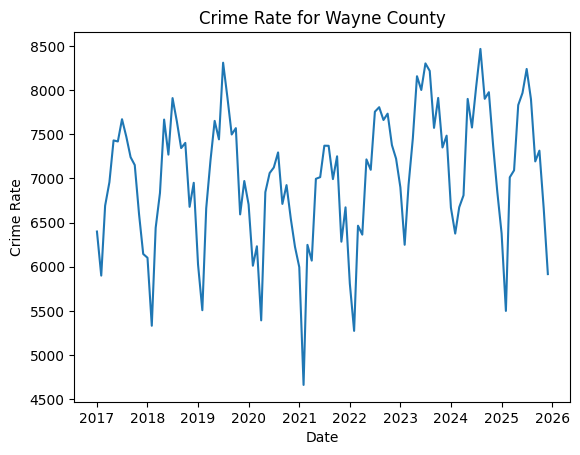

In [8]:
plt.figure()
plt.plot(crime['Date'],crime['Value'])
plt.xlabel("Date")
plt.ylabel("Crime Rate")
plt.title("Crime Rate for Wayne County")

plt.show()

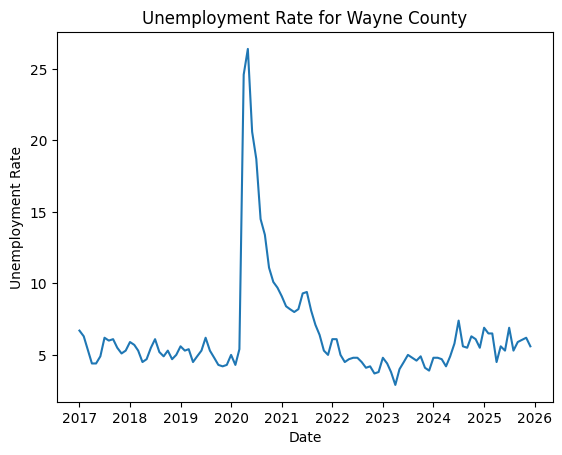

In [9]:
plt.figure()
plt.plot(unemployment['Date'],unemployment['Value'])
plt.xlabel("Date")
plt.ylabel("Unemployment Rate")
plt.title("Unemployment Rate for Wayne County")

plt.show()

# Initial ACF and PACF

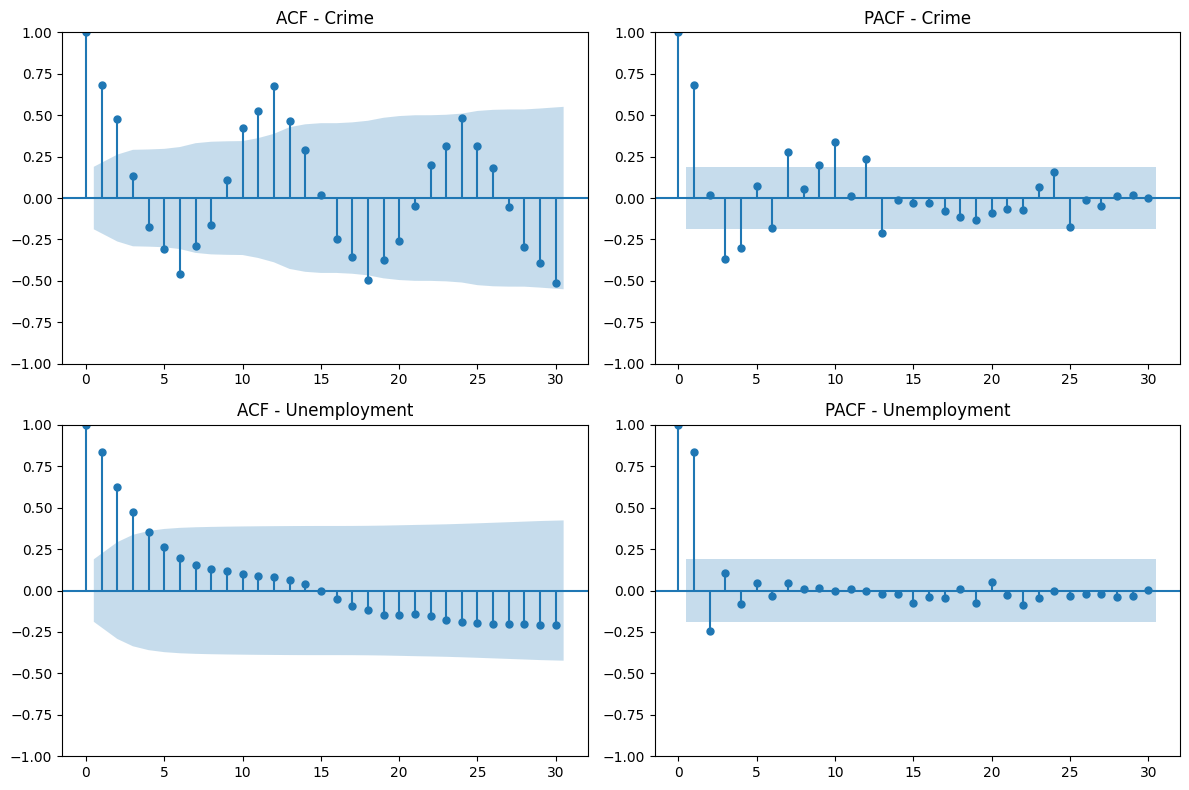

In [10]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

crime_series = crime["Value"]
unemp_series = unemployment["Value"]
lags = 30

fig, axes = plt.subplots(2, 2, figsize=(12, 8))


#Crime
plot_acf(crime_series, lags=lags, ax=axes[0, 0])
axes[0, 0].set_title("ACF - Crime")

plot_pacf(crime_series, lags=lags, ax=axes[0, 1])
axes[0, 1].set_title("PACF - Crime")

#Unemployment
plot_acf(unemp_series, lags=lags, ax=axes[1, 0])
axes[1, 0].set_title("ACF - Unemployment")

plot_pacf(unemp_series, lags=lags, ax=axes[1, 1])
axes[1, 1].set_title("PACF - Unemployment")

plt.tight_layout()
plt.show()


Based on this, we will need to do differencing first. 

Do I need to log difference crime???

For crime, I'll log difference, then seasonal difference (seasonal fluctuation

Unemployment is more straightforward, I can probably do a first differencing and then try out an AR(1) model

# Differencing

In [11]:

# crime, first log difference and then seasonal with 12 month
import numpy as np

crime["log_value"] = np.log1p(crime["Value"])

crime["Diff"] = (crime["log_value"].diff(12).diff(1)) #seasonal then first


# unemployment I can just use first differencing since the ACF plot seems to depend on the immediate lag
unemployment['Diff'] = unemployment['Value'].diff(1)



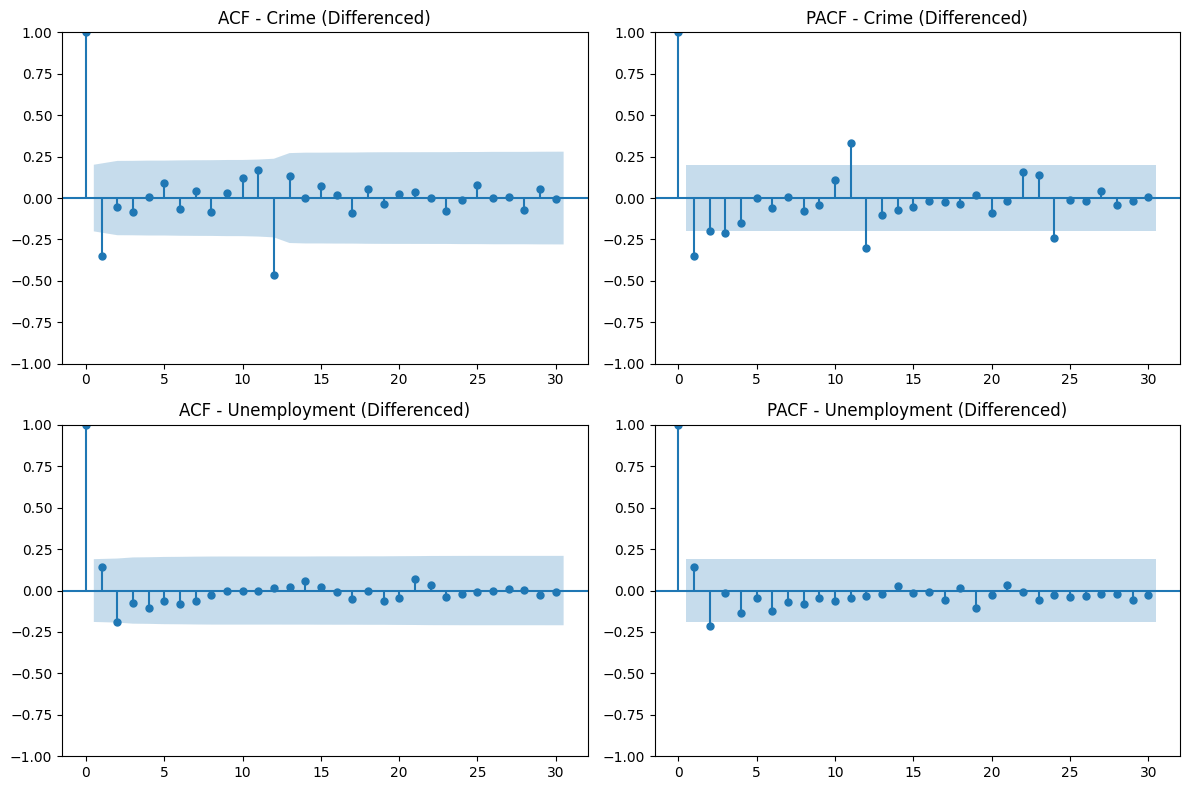

In [12]:

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

plot_acf(crime["Diff"].dropna(), lags=30, ax=axes[0,0])
axes[0,0].set_title("ACF - Crime (Differenced)")

plot_pacf(crime["Diff"].dropna(), lags=30, ax=axes[0,1])
axes[0,1].set_title("PACF - Crime (Differenced)")

plot_acf(unemployment["Diff"].dropna(), lags=30, ax=axes[1,0])
axes[1,0].set_title("ACF - Unemployment (Differenced)")

plot_pacf(unemployment["Diff"].dropna(), lags=30, ax=axes[1,1])
axes[1,1].set_title("PACF - Unemployment (Differenced)")

plt.tight_layout()
plt.show()


So now do I add a seasonal ma component to crime since like MA(1)? Since the lag spike is at 12?

What model would be best for unemployment since its just looking like a random walk?

We're trying to measure how 

# CCF

In [13]:
from statsmodels.tsa.stattools import ccf

df_diff = pd.concat(
    [crime["Diff"], unemployment["Diff"]],
    axis=1
).dropna()

df_diff.columns = ["crime_diff", "unemp_diff"]

ccf_vals = ccf(df_diff["unemp_diff"], df_diff["crime_diff"])


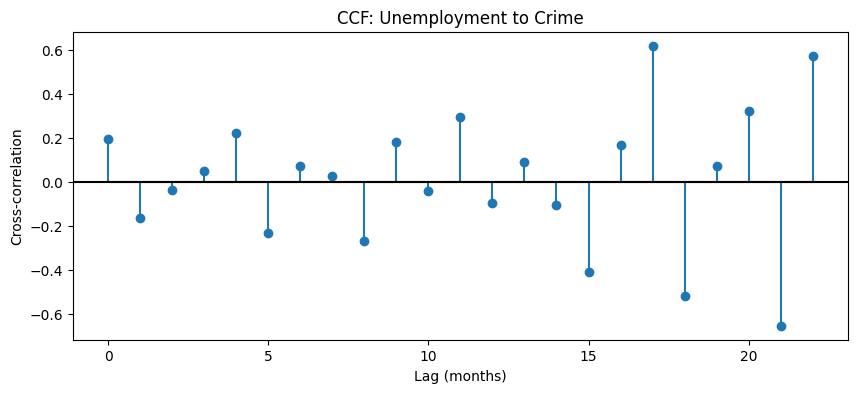

In [14]:
# Plot
plt.figure(figsize=(10, 4))
plt.stem(range(len(ccf_vals)), ccf_vals)
plt.axhline(0, color='black')
plt.title("CCF: Unemployment to Crime")
plt.xlabel("Lags (months)")
plt.ylabel("Cross-correlation")
plt.show()

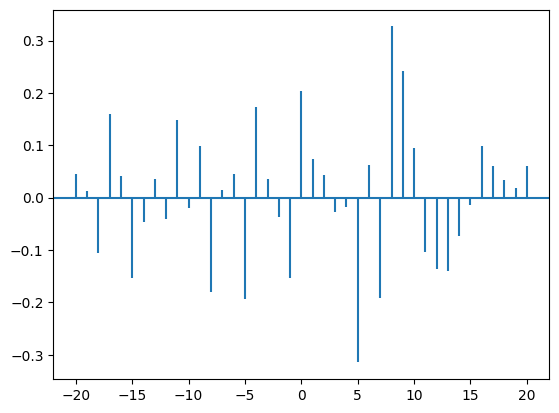

In [15]:
# ccf using xcor
# professor was worried about mix of positive and negative lags so I used xcor, it looks about the same though

plt.figure()
plt.xcorr(df_diff['crime_diff'], df_diff['unemp_diff'], maxlags=20)
plt.title("CCF: Unemployment to Crime")
plt.xlabel("Lag (months)")
plt.ylabel("Cross-correlation")
plt.show()
plt.show()

# Spectral Decomposition

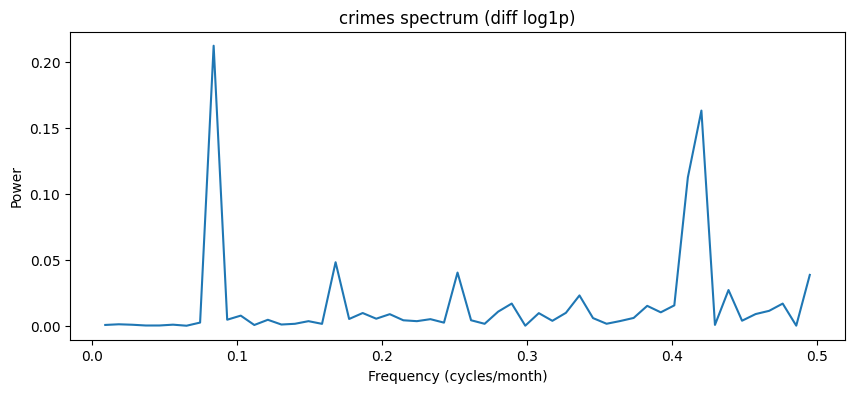

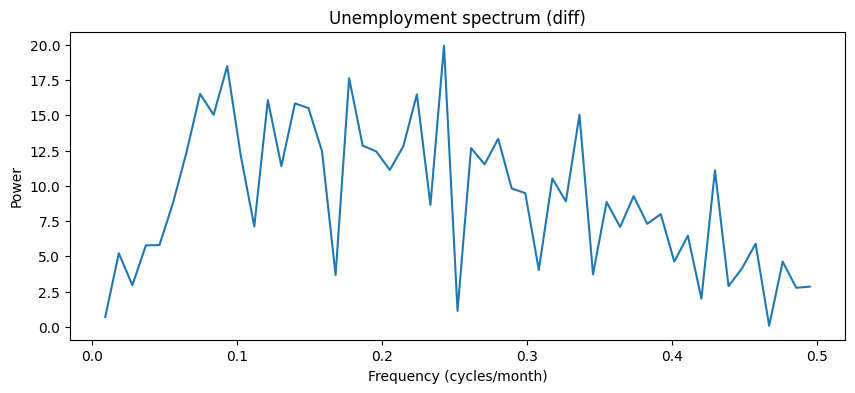

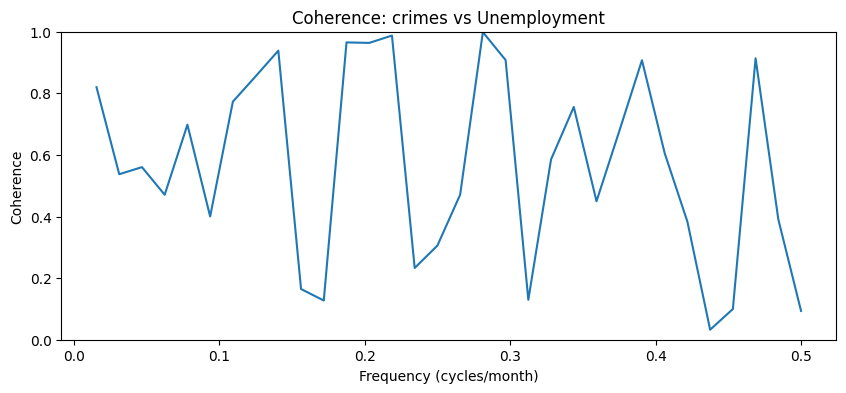

In [16]:
from scipy.signal import periodogram, csd, coherence



# align dataframes to same axes
crimes = crime.copy()
crimes["Date"] = pd.to_datetime(crimes["Date"], format="%Y %b")
crimes = crimes.set_index("Date")["Value"].asfreq("MS")

unemp = unemployment.copy()


#localize to same tz
unemp["Date"] = pd.to_datetime(unemp["Date"]).dt.tz_localize(None)
unemp = unemp.set_index("Date")["Value"].asfreq("MS")
crimes.index = crimes.index.tz_localize(None)

df = pd.concat([crimes, unemp], axis=1).dropna()
df.columns = ["crimes", "unemp"]


# difference the data
x = np.log1p(df["crimes"]).diff().dropna()
y = df["unemp"].diff().dropna()

# align after differencing
xy = pd.concat([x, y], axis=1).dropna()
x = xy.iloc[:,0].to_numpy()
y = xy.iloc[:,1].to_numpy()

fs = 1.0 


# for univariate spectragram
f_x, Pxx = periodogram(x, fs=fs, detrend="constant")
f_y, Pyy = periodogram(y, fs=fs, detrend="constant")


f_c, coh = coherence(x, y, fs=fs, nperseg=min(64, len(x)))
f_csd, Pxy = csd(x, y, fs=fs, nperseg=min(64, len(x)))
phase = np.angle(Pxy)  # radians




plt.figure(figsize=(10,4))
plt.plot(f_x[1:], Pxx[1:])
plt.title("crimes spectrum (diff log1p)")
plt.xlabel("Frequency (cycles/month)")
plt.ylabel("Power")
plt.show()

plt.figure(figsize=(10,4))
plt.plot(f_y[1:], Pyy[1:])
plt.title("Unemployment spectrum (diff)")
plt.xlabel("Frequency (cycles/month)")
plt.ylabel("Power")
plt.show()

plt.figure(figsize=(10,4))
plt.plot(f_c[1:], coh[1:])
plt.title("Coherence: crimes vs Unemployment")
plt.xlabel("Frequency (cycles/month)")
plt.ylabel("Coherence")
plt.ylim(0,1)
plt.show()